In [8]:
# ch2-4 keras를 이용한 와인데이터 분류용 DNN구현
# 4.1 와인데이터(winequality-red.csv)셋  : 12개 변수 설명
# 4.2 케라스를 이용한 DNN 모델 

from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Input, Dense, Dropout  
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

redwine = pd.read_csv("winequality-red.csv",sep=";")
redwine_X = redwine.iloc[:, :-1]
redwine_y = redwine.iloc[:, -1] - 3

from sklearn.model_selection import train_test_split 
train_X, test_X, train_y, test_y = train_test_split(redwine_X, redwine_y, test_size=0.3) 

scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)
test_X = scaler.transform(test_X)

model = Sequential()
model.add(Dense(100, input_shape=(11,), activation="sigmoid"))
model.add(Dropout(0.2))
model.add(Dense(200, activation="relu"))
model.add(Dropout(0.4))
model.add(Dense(50, activation="tanh"))
model.add(Dropout(0.1))
model.add(Dense(6, activation="softmax")) 

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

history = model.fit(train_X, train_y.to_numpy(), batch_size=200, epochs=50)

loss, accuracy = model.evaluate(test_X, test_y, verbose=1)

print("Loss :", loss)
print("Accuracy :", accuracy)

Epoch 1/50


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2976 - loss: 1.6376  
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4361 - loss: 1.3016 
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4522 - loss: 1.2280 
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4397 - loss: 1.1892 
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4870 - loss: 1.1665 
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4933 - loss: 1.1566 
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5058 - loss: 1.1251 
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4718 - loss: 1.1418 
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5085 - loss: 1.0862 
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5460 - loss: 1.0858 
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5308 - loss: 1.0517 
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5335 - loss: 1.0539 
Epoch 13/50

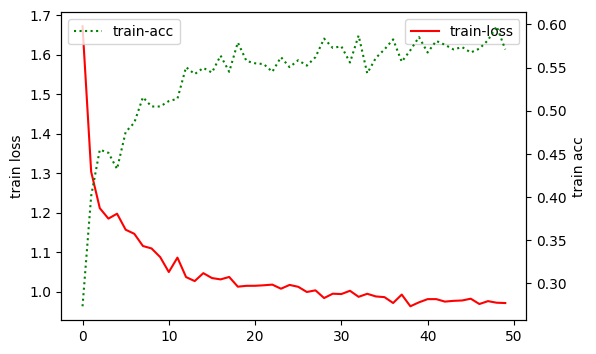

In [5]:
# 4.3 학습과정 시각화 

import matplotlib.pyplot as plt 

fig, ax1 = plt.subplots(figsize =(6,4)) 
ax1.plot(history.history["loss"], "r-", label="train-loss") 
ax1.set_ylabel("train loss")
ax1.legend()

ax2 = ax1.twinx()
ax2.plot(history.history["accuracy"], "g:", label="train-acc") 
ax2.set_ylabel("train acc")
ax2.legend()